# Test CrowdPoseLoader

This notebook verifies the correct functionality of `CrowdPoseLoader`:

1. Loads CrowdPose dataset annotations
2. Reads images with bounding boxes and keypoints
3. Visualizes crowded examples with annotated keypoints
4. Verifies the standardized `ImageSample` data structure

## 1. Import Libraries

In [1]:
import os
import sys
from pathlib import Path

# Resolve project root dynamically
project_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()),
    Path.cwd().parent
)
PROJECT_ROOT = project_root
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
mmpose_root = project_root / "models" / "mmpose"
if mmpose_root.exists() and str(mmpose_root) not in sys.path:
    sys.path.insert(0, str(mmpose_root))

print(f"Project root: {project_root}")

import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add project root to path

from pose_uncertainty.data_loader import CrowdPoseLoader

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Configure Dataset Paths

In [2]:
# CrowdPose dataset paths (relative to project root)
DATA_ROOT = project_root / "data" / "crowdpose"
ANN_FILE = "json/crowdpose_val.json"
IMAGE_DIR = "images"

print(f"Data Root: {DATA_ROOT}")
print(f"Annotation File: {ANN_FILE}")
print(f"Image Directory: {IMAGE_DIR}")
print(f"\nChecking if files exist...")
print(f"  - Annotation exists: {(DATA_ROOT / ANN_FILE).exists()}")
print(f"  - Image dir exists: {(DATA_ROOT / IMAGE_DIR).exists()}")

Data Root: c:\Users\USUARIO\Desktop\Universidad\TFG_Informatica\robust-pose-tta\data\crowdpose
Annotation File: json/crowdpose_val.json
Image Directory: images

Checking if files exist...
  - Annotation exists: True
  - Image dir exists: True


## 3. Initialize CrowdPoseLoader

In [3]:
loader = CrowdPoseLoader(
    data_root=str(DATA_ROOT),
    ann_file=ANN_FILE,
    image_dir=IMAGE_DIR
)

print(f"\n✓ CrowdPoseLoader initialized successfully")
print(f"  Total images available: {len(loader)}")

Cargando anotaciones desde c:\Users\USUARIO\Desktop\Universidad\TFG_Informatica\robust-pose-tta\data\crowdpose\json/crowdpose_val.json...
loading annotations into memory...
Done (t=0.15s)
creating index...
index created!
Dataset cargado: 2000 imágenes encontradas.

✓ CrowdPoseLoader initialized successfully
  Total images available: 2000


## 4. Load First Sample

In [4]:
# Get first sample from iterator
sample_iter = iter(loader)
sample = next(sample_iter)

print(f"Sample loaded successfully!")
print(f"  - Image ID: {sample.image_id}")
print(f"  - Image Path: {sample.image_path}")
print(f"  - Image Shape: {sample.image_array.shape}")
print(f"  - BBox (x,y,w,h): {sample.bbox}")
print(f"  - Dataset Source: {sample.dataset_source}")
print(f"  - Number of keypoints: {len(sample.ground_truth_keypoints)}")

Sample loaded successfully!
  - Image ID: 106502
  - Image Path: c:\Users\USUARIO\Desktop\Universidad\TFG_Informatica\robust-pose-tta\data\crowdpose\images\106502.jpg
  - Image Shape: (480, 640, 3)
  - BBox (x,y,w,h): (193.41, 59.87, 190.75, 136.02)
  - Dataset Source: crowdpose
  - Number of keypoints: 14


## 5. Visualize Sample with Keypoints

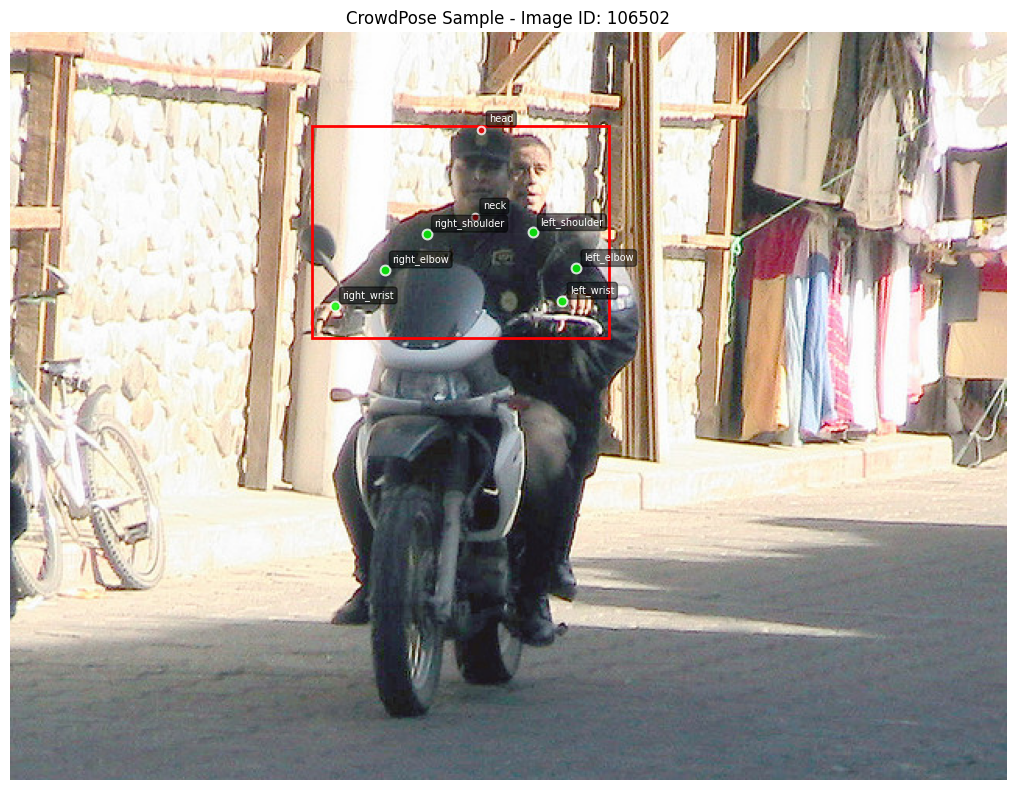

In [5]:
def visualize_sample(sample):
    """
    Visualize image with bounding box and keypoints.
    """
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Display image
    ax.imshow(sample.image_array)
    
    # Draw bounding box
    x, y, w, h = sample.bbox
    from matplotlib.patches import Rectangle
    rect = Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    
    # Draw keypoints with different colors based on confidence
    for kp in sample.ground_truth_keypoints:
        if kp.confidence > 0.0:
            # Color based on confidence: red (occluded) to green (visible)
            color = 'red' if kp.confidence == 0.5 else 'lime'
            size = 50 if kp.confidence == 1.0 else 30
            ax.scatter(kp.x, kp.y, c=color, s=size, alpha=0.8, edgecolors='white', linewidths=1.5)
            # Add keypoint name label
            ax.text(kp.x + 5, kp.y - 5, kp.name, fontsize=7, color='white', 
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.5))
    
    ax.set_title(f"CrowdPose Sample - Image ID: {sample.image_id}")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize_sample(sample)

## 6. Verify Keypoint Structure

In [6]:
print("Detailed Keypoint Information:")
print("=" * 80)
for kp in sample.ground_truth_keypoints:
    print(f"ID: {kp.id:2d} | Name: {kp.name:15s} | "
          f"Position: ({kp.x:6.1f}, {kp.y:6.1f}) | Confidence: {kp.confidence:.1f}")

Detailed Keypoint Information:
ID:  0 | Name: left_shoulder   | Position: ( 335.0,  128.0) | Confidence: 1.0
ID:  1 | Name: right_shoulder  | Position: ( 267.0,  129.0) | Confidence: 1.0
ID:  2 | Name: left_elbow      | Position: ( 363.0,  151.0) | Confidence: 1.0
ID:  3 | Name: right_elbow     | Position: ( 240.0,  152.0) | Confidence: 1.0
ID:  4 | Name: left_wrist      | Position: ( 354.0,  172.0) | Confidence: 1.0
ID:  5 | Name: right_wrist     | Position: ( 208.0,  175.0) | Confidence: 1.0
ID:  6 | Name: left_hip        | Position: (   0.0,    0.0) | Confidence: 0.0
ID:  7 | Name: right_hip       | Position: (   0.0,    0.0) | Confidence: 0.0
ID:  8 | Name: left_knee       | Position: (   0.0,    0.0) | Confidence: 0.0
ID:  9 | Name: right_knee      | Position: (   0.0,    0.0) | Confidence: 0.0
ID: 10 | Name: left_ankle      | Position: (   0.0,    0.0) | Confidence: 0.0
ID: 11 | Name: right_ankle     | Position: (   0.0,    0.0) | Confidence: 0.0
ID: 12 | Name: head            | 

## 7. Dataset Statistics & Visibility

In [7]:
# Count keypoints by visibility
visible = sum(1 for kp in sample.ground_truth_keypoints if kp.confidence == 1.0)
occluded = sum(1 for kp in sample.ground_truth_keypoints if kp.confidence == 0.5)
not_labeled = sum(1 for kp in sample.ground_truth_keypoints if kp.confidence == 0.0)

print("Keypoint Visibility Statistics:")
print(f"  Visible (confidence=1.0): {visible}/{len(sample.ground_truth_keypoints)}")
print(f"  Occluded (confidence=0.5): {occluded}/{len(sample.ground_truth_keypoints)}")
print(f"  Not Labeled (confidence=0.0): {not_labeled}/{len(sample.ground_truth_keypoints)}")

Keypoint Visibility Statistics:
  Visible (confidence=1.0): 6/14
  Occluded (confidence=0.5): 2/14
  Not Labeled (confidence=0.0): 6/14


## 8. Test Lazy Loading (Multiple Iterations)

In [8]:
# Test that we can iterate multiple times
print("Testing lazy loading with multiple samples...")
sample_count = 0
for sample in loader:
    sample_count += 1
    if sample_count >= 5:  # Load only 5 samples for test
        break
    print(f"  Sample {sample_count}: ID={sample.image_id}, Shape={sample.image_array.shape}")

print(f"\n✓ Successfully loaded {sample_count} samples with lazy loading")

Testing lazy loading with multiple samples...
  Sample 1: ID=106502, Shape=(480, 640, 3)
  Sample 2: ID=106508, Shape=(427, 640, 3)
  Sample 3: ID=106513, Shape=(427, 640, 3)
  Sample 4: ID=106516, Shape=(640, 480, 3)

✓ Successfully loaded 5 samples with lazy loading


## 9. Visualize Multiple Samples

Visualizing 3 random samples from CrowdPose...

Sample 1:


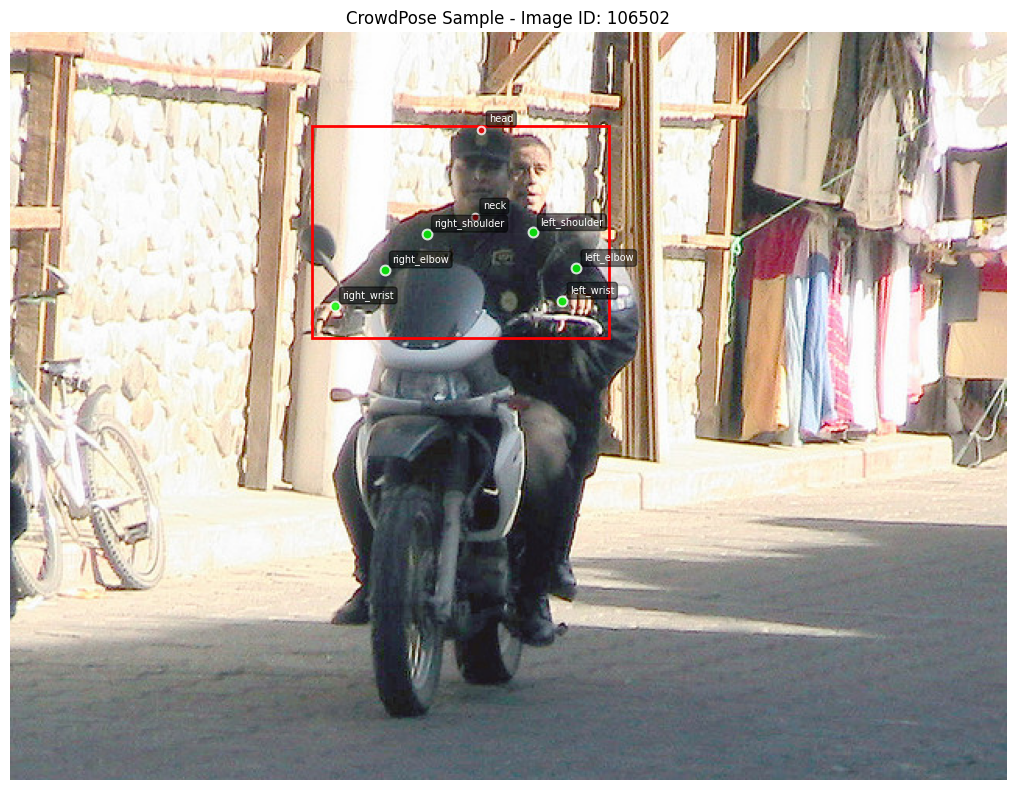


Sample 2:


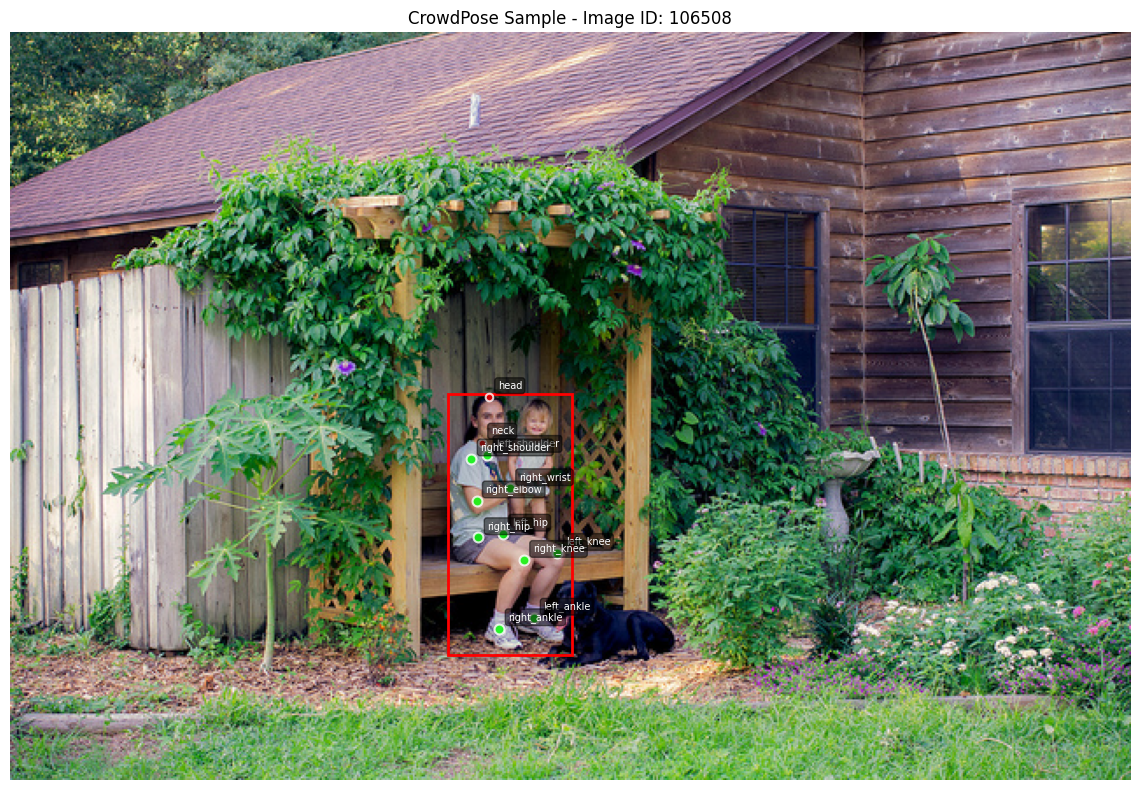


Sample 3:


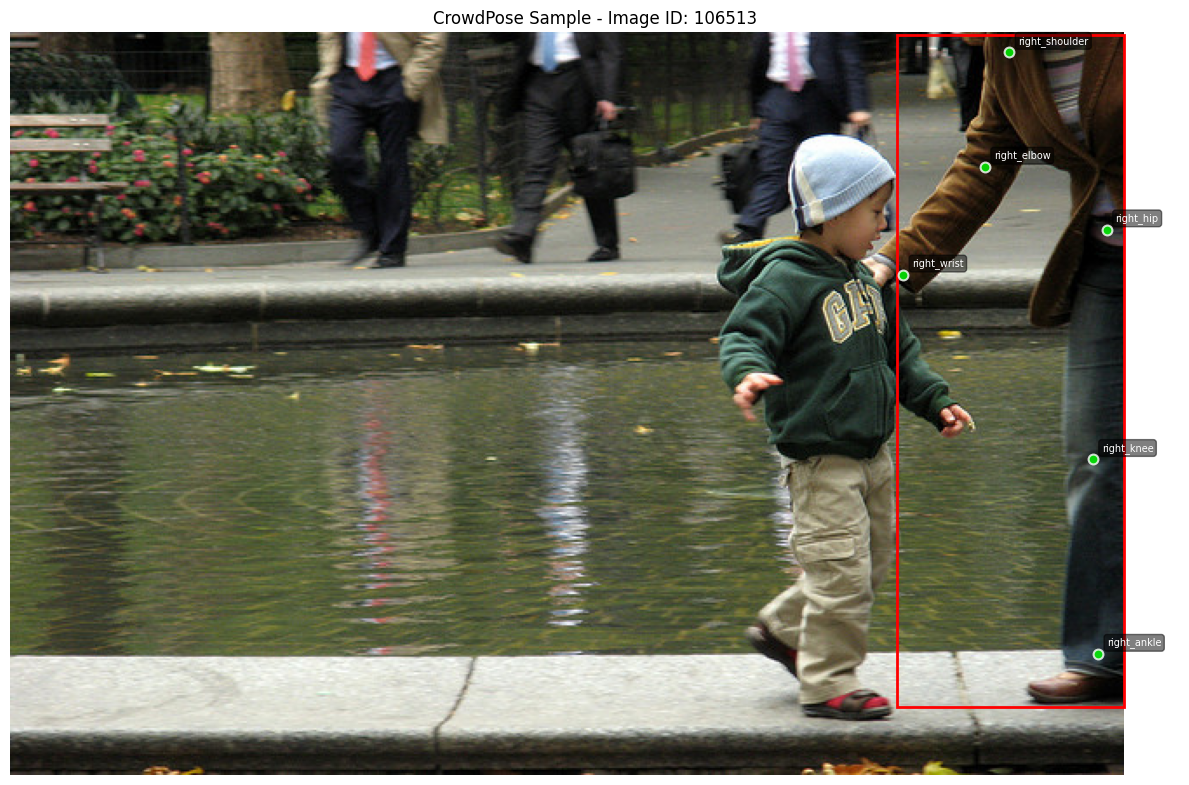

In [9]:
# Visualize 3 different samples
print("Visualizing 3 random samples from CrowdPose...")
sample_iter = iter(loader)

for i in range(3):
    sample = next(sample_iter)
    print(f"\nSample {i+1}:")
    visualize_sample(sample)

## 10. Summary

✅ **CrowdPoseLoader Verification Complete**

The CrowdPoseLoader has been successfully validated:
- ✓ Loads CrowdPose annotations correctly
- ✓ Parses 14 keypoints properly
- ✓ Implements lazy loading (images loaded on demand)
- ✓ Returns ImageSample objects with correct structure
- ✓ Visualizes keypoints and bounding boxes accurately

**Key Differences from COCO:**
- CrowdPose defines **14 keypoints** (vs COCO's 17)
- Different keypoint topology (omits facial keypoints, adds head and neck)
- Tailored for high occlusion and multi-person crowding scenarios.